In [ ]:
import cafe

# cafe.logger.setLevel("DEBUG")

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

DEBUG    |- Reading data from '/root/PyCode/scRNA/data/BoneMarrow/setty_bone_marrow.h5ad'...                                                                                                            
DEBUG    |- transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                               

AnnData object with n_obs × n_vars = 5780 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'raw_index'
    var: 'palantir'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types', 'id', 'cafe', 'filename'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs'
    layers: 'spliced', 'unspliced', 'expression', 'counts'

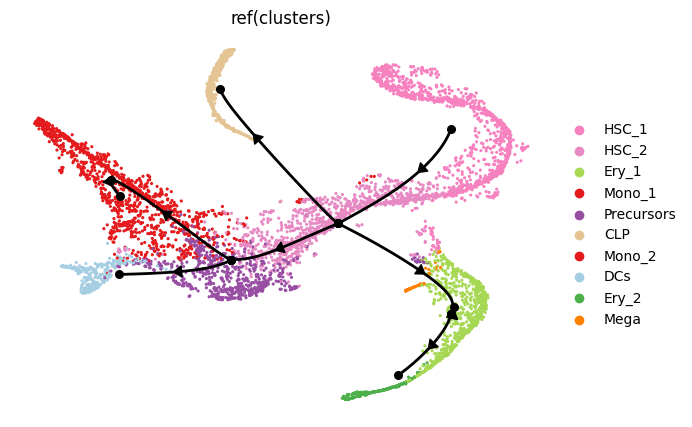

In [2]:
fadata = cafe.data.read_bonemarrow()
cafe.plot.plot_trajectory(fadata) # waypoint wrapper
fadata

benchmark method run

In [3]:
fadata = cafe.benchmark.run(fadata)

INFO     |- no method_parameter_dict or method_yaml_file provided, use default method yaml file(.cafe/bonemarrow/benchmark/methods.yaml)                                                                
INFO     |- load method_parameter_dict from yaml file '.cafe/bonemarrow/benchmark/methods.yaml'                                                                                                         
INFO     |- result for scvelo already exists, load cached result                                                                                                                                        
INFO     |- result for comp1 already exists, load cached result                                                                                                                                         
INFO     |- all methods have run.                                                                                                                                                                   

In [4]:
# model_name = "comp1"
# fadata.load_trajectory_dict([model_name])
# cafe.plot.plot_trajectory(fadata, model_name=model_name)
# fadata.get_waypoint_wrapper(model_name) # waypont wrapper

benchmark method caculation

In [4]:
benchmark_df = cafe.benchmark.metrics(fadata, overall_score_func=True, if_save=True, if_impute=False)
benchmark_df

INFO     |- no model_name_list provided, use all methods in method yaml file: ['scvelo', 'comp1']                                                                                                       
INFO     |- metric file for model 'scvelo' already exists. read it.                                                                                                                                     
INFO     |- metric file for model 'comp1' already exists. read it.                                                                                                                                      
INFO     |- model comp1 missing metrics: ['pseudotime_correlation'], recalculating...                                                                                                                   
DEBUG    |- 'ref' is not a valid random_time_string, don't need parse                                                                                                                               

,pseudotime_correlation,velocity_cbdir,velocity_icvcoh,correlation,rf_mse,rf_nmse,rf_rsq,lm_nmse,lm_mse,lm_rsq,...,F1_branches,F1_milestones,harm_mean,geom_mean,arith_mean,time,time_text,memory,memory_text,overall
scvelo,0.49332,0.412596,0.824687,0.527193,0.994138,0.973634,0.925610,0.958251,0.990717,0.888531,...,0.692124,0.877635,0.877635,0.877635,0.877635,0.0,0s,0.0,0M,0.576841
comp1,0.49761,0.327687,0.999920,0.000000,0.842740,0.292738,0.231232,0.170458,0.815550,0.125461,...,0.156612,0.247027,0.247027,0.247027,0.247027,0.0,0s,0.0,0M,0.231711


benchmark visualization

No legends were provided, trying to automatically infer legends.
Some palettes were not used in the column info, adding legends for them:metric_palette, overall_palette, white6black4, resource_palette
Legend {'title': 'metric_palette', 'palette': 'metric_palette', 'enabled': True} did not contain a geom, inferring from the column_info.
Legend {'title': 'metric_palette', 'palette': 'metric_palette', 'enabled': True, 'geom': 'funkyrect'} did not contain labels, inferring from the geom.
Legend {'title': 'metric_palette', 'palette': 'metric_palette', 'enabled': True, 'geom': 'funkyrect', 'labels': ['0', '', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1']} did not contain size, inferring from the labels.
Legend {'title': 'metric_palette', 'palette': 'metric_palette', 'enabled': True, 'geom': 'funkyrect', 'labels': ['0', '', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1'], 'size': [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]} did not

<Figure size 3200x2400 with 0 Axes>

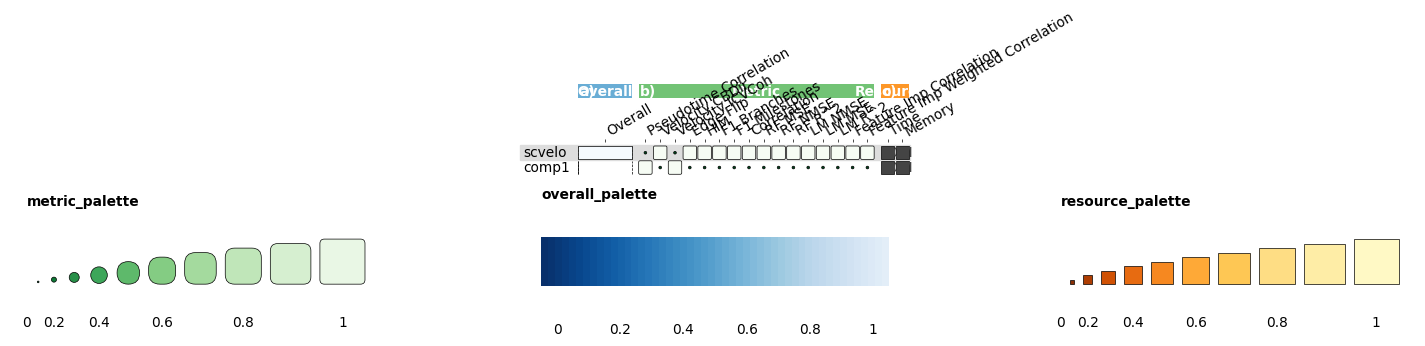

In [5]:
cafe.benchmark.visualize(benchmark_df)